<a href="https://colab.research.google.com/github/Lucius-40/Computer-Vision-Projects/blob/main/CIFAR-10/object_detection_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import numpy as np
import pandas as pd
import random
import torch
import torchvision
import torchvision.transforms as transforms
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import torch.optim as optim
import os
from tqdm import tqdm

In [3]:
import torchvision.models as models


Access the GPU if Available .

In [4]:
print("CUDA available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
else:
    print("No GPU detected")

CUDA available: True
Using device: cuda
GPU name: Tesla T4


The mean and std deviations are readily obtainable from the cifar-10 dataset. We use that to normalize each of the pixel values. Besides that , we apply 2 relatively weak augmentations, as the cifar-10 dataset has small 32x32 images that are blurry, strong augmentation produces large errors. We convert the images to tensors for Pytorch optimizations

In [5]:
mean = (0.4914, 0.4822, 0.4465)
std = (0.2023, 0.1994, 0.2010)
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

train_set = torchvision.datasets.CIFAR10(root='.', train=True,download=True, transform=transform_train)
test_set = torchvision.datasets.CIFAR10(root='.', train=False , download=True, transform=transform_test)

train_loader = DataLoader(train_set, batch_size=254, shuffle=True)
test_loader = DataLoader(test_set, batch_size=254, shuffle=False)

100%|██████████| 170M/170M [00:13<00:00, 13.0MB/s]


To Take a look at the samples from the dataset.

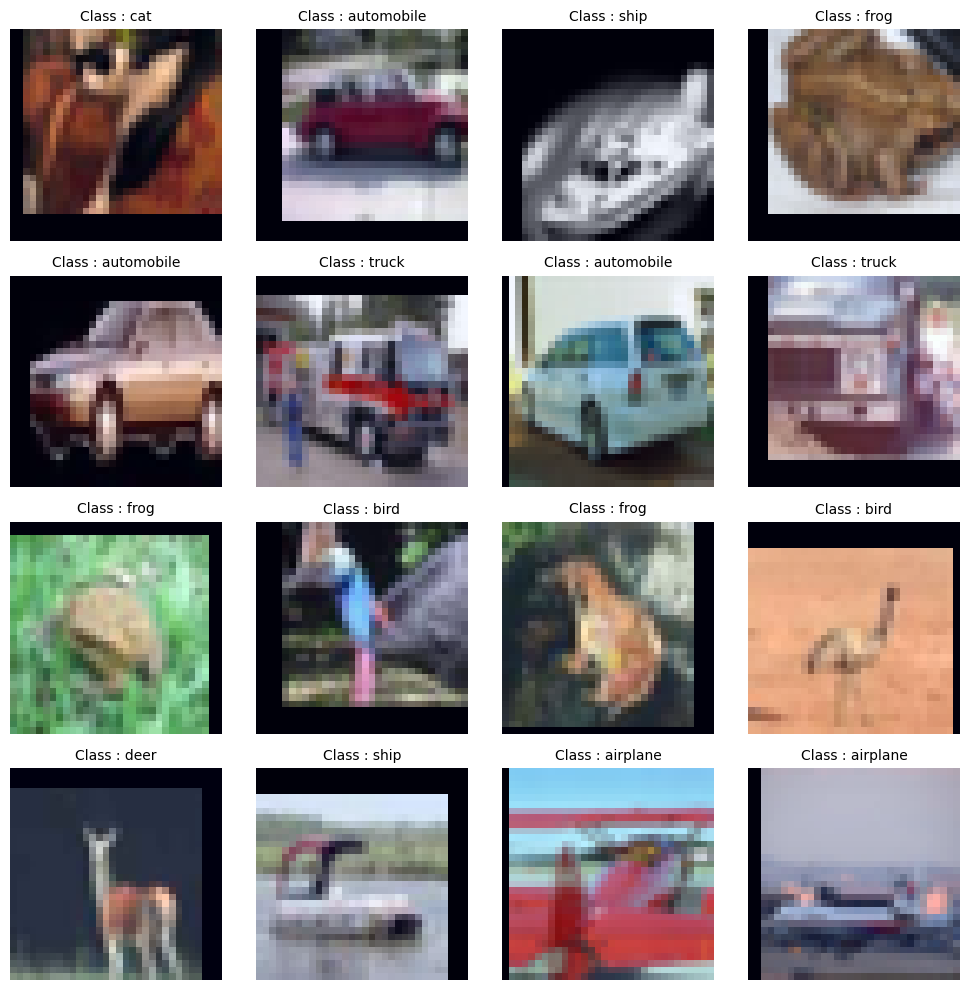

In [6]:
rand_idx = random.sample(range(len(train_set)), k=16)

plt.figure(figsize=(10,10))

for i, idx in enumerate(rand_idx):
    img, label = train_set[idx]

    # scale to [0,1] for display
    img = (img - img.min()) / (img.max() - img.min())

    img_class = train_set.classes[label]

    plt.subplot(4,4,i+1)
    plt.imshow(img.permute(1,2,0))
    plt.title(f"Class : {img_class}", fontsize=10)
    plt.axis(False)

plt.tight_layout()
plt.show()

### ResNet-18 Modifications for CIFAR-10

- **Initialization**: We set `weights=None`, meaning the model is trained from scratch without using any pretrained ImageNet weights.  
- **Output Classes**: `num_classes=10` ensures the final fully connected layer outputs 10 logits, one for each CIFAR-10 class.  
- **First Convolution Layer**:  
  - By default, ResNet-18 uses a `7×7` kernel with stride `2`, which downsamples aggressively.  
  - This is suitable for large ImageNet images (224×224), but not for small CIFAR-10 images (32×32).  
  - We replace it with a `3×3` kernel, stride `1`, and padding `1` to better preserve spatial details.  
- **MaxPooling Layer**:  
  - The original ResNet applies a `3×3` maxpool with stride `2` immediately after the first convolution.  
  - On 32×32 inputs, this reduces resolution too quickly and discards important information.  
  - We replace it with `nn.Identity()`, which effectively removes the pooling step and keeps the resolution intact.  

**Result**: These adjustments adapt ResNet-18 to small-scale datasets like CIFAR-10 by preserving more spatial information in the early layers, leading to better performance.

In [7]:
model = models.resnet18(weights=None, num_classes=10)
model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
model.maxpool = nn.Identity()  # remove the first maxpool

In [8]:
model = model.to(device)

### Loss Function, Optimizer, and Scheduler Setup

- **Loss Function**:  
  - For **multi-class classification** (like CIFAR-10), **CrossEntropyLoss** is the standard choice.  
  - Note: *Multi-label* classification (where each sample can belong to multiple classes simultaneously) usually uses **BCEWithLogitsLoss** instead.  

- **Optimizer**:  
  - **SGD (Stochastic Gradient Descent)** is a common optimizer for training CNNs, especially when combined with momentum and learning rate scheduling.  
  - **Adam** can also work well, but SGD often generalizes better in vision tasks when tuned properly.  

- **Learning Rate (LR)**:  
  - A relatively high initial learning rate (e.g., `0.1`) is often used with SGD.  
  - Since we also use a **learning rate scheduler**, the LR will be adjusted over time to stabilize training.  

- **Momentum**:  
  - Momentum helps accelerate gradients in the right direction and dampens oscillations.  
  - It does **not directly change the learning rate**, but it makes updates more consistent by accumulating past gradients.  

- **Weight Decay (L2 Regularization)**:  
  - Adds a penalty proportional to the square of the weights to the loss function.  
  - This discourages large weights, helping to reduce overfitting and improve generalization.  

- **Learning Rate Scheduler**:  
  - A **CosineAnnealingLR** scheduler is often used.  
  - The parameter `T_max` specifies the maximum number of epochs for one cosine cycle.  
  - The learning rate decreases following a cosine curve, starting high and gradually annealing towards a minimum value.  

**Summary**:  
This setup (**CrossEntropyLoss + SGD with momentum + weight decay + cosine annealing scheduler**) is a standard and effective recipe for training ResNet-style models on CIFAR-10.

In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=200)

To store training and validation data for visualization later

In [10]:
history = {
    "train_loss": [],
    "test_loss": [],
    "train_acc": [],
    "test_acc": []
}

Here, the model is trained and the loss and accuracy per epoch are recorded, and includes a progressbar to show training progress.

In [ ]:

for epoch in range(200):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/200 [Train]", leave=False):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total

    # --- validation ---
    model.eval()
    test_loss, correct_test, total_test = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc=f"Epoch {epoch+1}/200 [Test]", leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            test_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()

    test_loss /= len(test_loader)
    test_acc = 100 * correct_test / total_test

    scheduler.step()

    # ✅ store metrics in dictionary
    history["train_loss"].append(train_loss)
    history["test_loss"].append(test_loss)
    history["train_acc"].append(train_acc)
    history["test_acc"].append(test_acc)

    print(f"Epoch [{epoch+1}/200] "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% "
          f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")

Epoch [1/200] Train Loss: 1.9509 | Train Acc: 29.81% Test Loss: 1.4758 | Test Acc: 43.86%


Epoch [2/200] Train Loss: 1.3560 | Train Acc: 50.34% Test Loss: 1.2309 | Test Acc: 56.49%


Epoch [3/200] Train Loss: 1.0656 | Train Acc: 61.83% Test Loss: 1.1012 | Test Acc: 61.51%


Epoch [4/200] Train Loss: 0.8764 | Train Acc: 69.06% Test Loss: 0.8611 | Test Acc: 70.17%


Epoch [5/200] Train Loss: 0.7268 | Train Acc: 74.43% Test Loss: 0.7530 | Test Acc: 73.57%


...

Epoch [152/200] Train Loss: 0.0128 | Train Acc: 99.60% Test Loss: 0.2373 | Test Acc: 93.89%


Epoch [153/200] Train Loss: 0.0102 | Train Acc: 99.73% Test Loss: 0.2339 | Test Acc: 94.08%


Epoch [154/200] Train Loss: 0.0085 | Train Acc: 99.77% Test Loss: 0.2383 | Test Acc: 93.72%


Epoch [155/200] Train Loss: 0.0090 | Train Acc: 99.74% Test Loss: 0.2310 | Test Acc: 94.20%


Epoch 156/200 [Train]:  88%|████████▊ | 173/197 [00:50<00:07,  3.27it/s]

I had hit 94& accuracy when colab disconnected and I did not save the model :(((((((

In [1]:
model.eval()
test_loss = 0.0
correct_test = 0
total_test = 0

with torch.no_grad():
    for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            test_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()

    test_loss /= len(test_loader)
    test_acc = 100 * correct_test / total_test




    print(f"Epoch [{epoch+1}/70] "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% "
          f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")


NameError: name 'model' is not defined